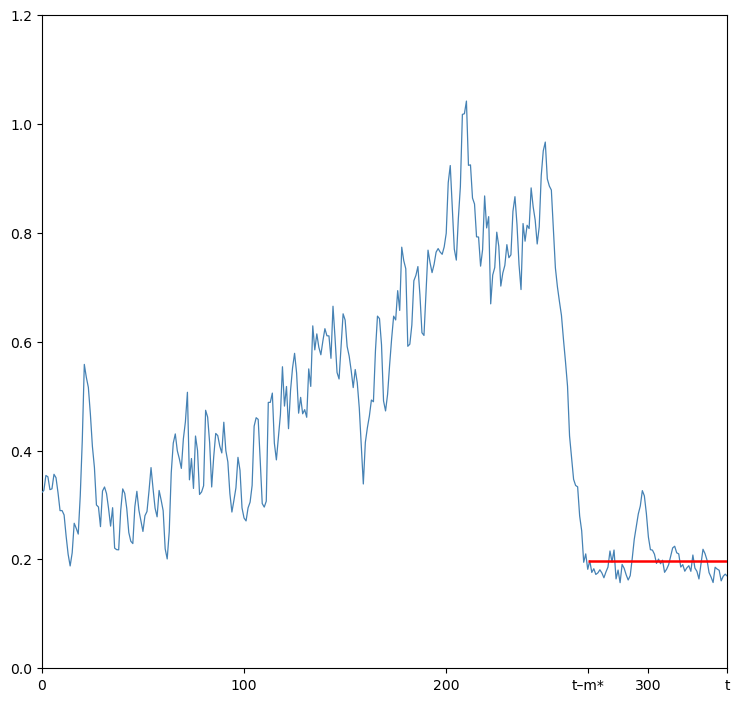

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.ndimage import uniform_filter1d

np.random.seed(42)

def make_theta_series():
    # Phase I (0..59): low ~0.30 with a local spike
    p1    = 0.30 + 0.08 * np.random.randn(60)
    spike = np.zeros(60)
    spike[20:28] = [0.12, 0.25, 0.30, 0.28, 0.22, 0.15, 0.08, 0.03]
    p1   += spike

    # Phase II (60..249): rising trend + high noise + oscillation + mid-dip
    trend = np.linspace(0.28, 0.90, 190)
    noise = 0.12 * np.random.randn(190)
    osc   = 0.07 * np.sin(np.linspace(0, 6 * np.pi, 190))
    dip   = np.zeros(190)
    dip[90:110] = -np.hanning(20) * 0.18
    p2    = trend + noise + osc + dip

    # Break (250..269): sharp drop
    p3 = np.linspace(0.90, 0.18, 20) + 0.04 * np.random.randn(20)

    # Phase III (270..339): stable ~0.18 with a small transient bump
    p4   = 0.18 + 0.045 * np.random.randn(70)
    bump = np.zeros(70)
    bump[20:35] = np.hanning(15) * 0.12
    p4  += bump

    raw   = np.concatenate([p1, p2, p3, p4])
    theta = uniform_filter1d(raw, size=3, mode='nearest')  # light smoothing
    return np.clip(theta, 0.0, 1.2)

theta  = make_theta_series()
T      = len(theta)   # 340
K_STAR = 270
mean_h = theta[K_STAR:].mean()

fig, ax = plt.subplots(figsize=(7.5, 7.5))

ax.plot(np.arange(T), theta, color='steelblue', linewidth=0.9, zorder=3)
ax.hlines(mean_h, K_STAR, T - 1, colors='red', linewidth=1.8, zorder=4)

ax.set_xlim(0, T - 1)
ax.set_ylim(0, 1.2)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))

x_positions = [0, 100, 200, K_STAR, 300, T - 1]
x_labels    = ['0', '100', '200', 't–m*', '300', 't']
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=10)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('fig44_local_parametric.png', dpi=200, bbox_inches='tight',transparent=True)
plt.show()